## Group Visualizations

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np
import pandas as pd

from src.config import PROCESSED_DATA_DIR

from scipy.signal import savgol_filter
from statsmodels.nonparametric.smoothers_lowess import lowess

def loess_smooth(group, x_col, y_col, frac=0.3):
    smoothed = lowess(group[y_col].values, group[x_col].values, frac=frac, return_sorted=False)
    return pd.Series(smoothed, index=group.index)

2026-05-12 19:21:45.318 | INFO     | src.config:<module>:11 - PROJ_ROOT path is: /Users/virginia/Desktop/GitHub/cycle-tracking/cycle-tracking


In [2]:
PHASE_ORDER = ["Menstrual", "Follicular", "Fertility", "Luteal"]
PHASE_COLORS = {
    "Menstrual": "#d62728",
    "Follicular": "#1f77b4",
    "Fertility": "#2ca02c",
    "Luteal": "#9467bd",
}
REPORT_COLS = [
    "appetite", "exerciselevel", "headaches", "cramps", "sorebreasts",
    "fatigue", "sleepissue", "moodswing", "stress", "foodcravings",
    "indigestion", "bloating",
]

def ci95(series):
    n = series.count()
    if n < 2:
        return float("nan")
    return 1.96 * series.std() / np.sqrt(n)

In [3]:
interday = pd.read_csv(PROCESSED_DATA_DIR / "features_interday.csv")
intraday = pd.read_csv(PROCESSED_DATA_DIR / "features_intraday.csv", parse_dates=["datetime"])

print(f"Interday: {interday.shape}")
print(f"Intraday: {intraday.shape}")

Interday: (3230, 45)
Intraday: (847872, 15)


In [4]:
print(f"All cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")
interday = interday[interday["is_complete_cycle"]].copy()
complete_pairs = interday[["id", "cycle_id"]].drop_duplicates()
intraday = intraday.merge(complete_pairs, on=["id", "cycle_id"])
print(f"Complete cycles: {interday.groupby(['id','cycle_id']).ngroups}  |  subjects: {interday['id'].nunique()}")

All cycles: 126  |  subjects: 38
Complete cycles: 88  |  subjects: 37


### Cycle length and phase duration distributions

Cycle length (days): mean = 29.33, sd = 5.57


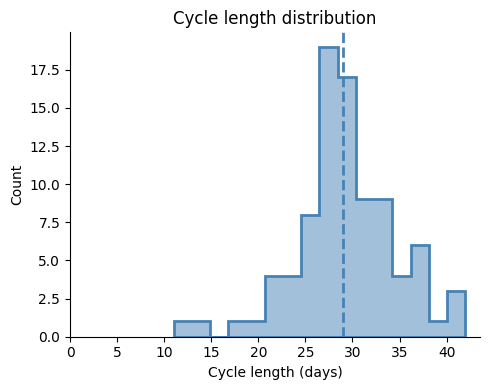

In [12]:
cycle_lengths = interday.groupby(["id", "cycle_id"])["cycle_day"].max()
print(f"Cycle length (days): mean = {cycle_lengths.mean():0.2f}, sd = {cycle_lengths.std():0.2f}")

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(cycle_lengths, bins=16, 
        histtype="stepfilled",
        facecolor=mcolors.to_rgba("steelblue", alpha=0.5),
        edgecolor="steelblue", 
        linewidth=2)
ax.axvline(cycle_lengths.median(), color="steelblue", linewidth=2, linestyle="--")
ax.set_xlabel("Cycle length (days)")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, None)
ax.set_title("Cycle length distribution")
fig.tight_layout()
plt.show()

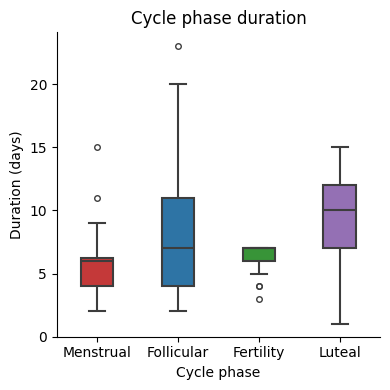

In [13]:
phase_dur = (
    interday.dropna(subset=["phase"])
    .groupby(["id", "cycle_id", "phase"])
    .size()
    .reset_index(name="days")
)

fig, ax = plt.subplots(figsize=(4, 4))
sns.boxplot(data=phase_dur, x="phase", y="days",
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4})

ax.set_xlabel("Cycle phase")
ax.set_ylabel("Duration (days)")
ax.set_ylim(0, None)
ax.spines[["top", "right"]].set_visible(False)
ax.set_title("Cycle phase duration")
fig.tight_layout()
plt.show()

### Hormones across study days and cycle progression

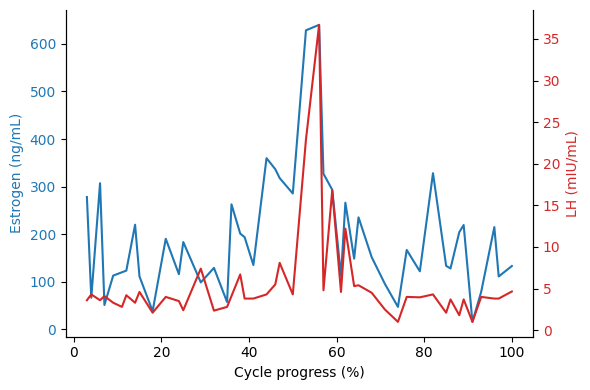

In [22]:
df = interday.dropna(subset=["estrogen", "lh"]).copy()
for col in ["estrogen", "lh"]:
    df[f"{col}_smooth"] = (
        df.groupby(["id", "cycle_id"])[col]
        .transform(lambda x: pd.Series(savgol_filter(x.values, window_length=7, polyorder=2), index=x.index))
    )

df["pct_bin"] = df["cycle_pct"].round(0).astype(int)
by_pct = (
    df.groupby(["id", "pct_bin"])[["estrogen", "lh"]]
    .mean()
    .reset_index()
)
fig, ax1 = plt.subplots(figsize=(6, 4))
ax2 = ax1.twinx()

sns.lineplot(data=by_pct[by_pct['id'] == 4], x="pct_bin", y="estrogen", ax=ax1, color="tab:blue")
sns.lineplot(data=by_pct[by_pct['id'] == 4], x="pct_bin", y="lh", ax=ax2, color="tab:red")

ax1.set_ylabel("Estrogen (ng/mL)", color="tab:blue")                                                                    
ax2.set_ylabel("LH (mIU/mL)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")  
ax1.set_xlabel("Cycle progress (%)")
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)

fig.tight_layout()
plt.show()

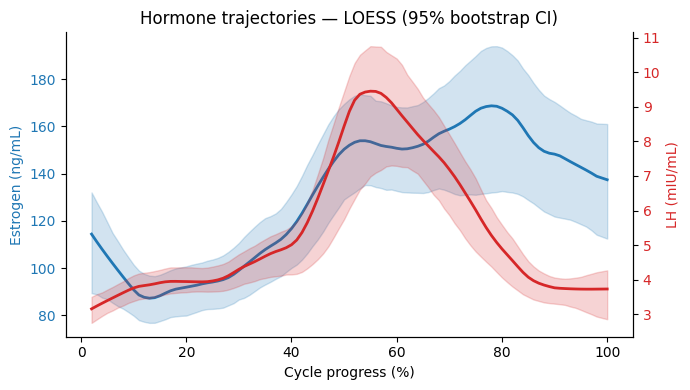

In [ ]:
df_cmp = interday.dropna(subset=["estrogen", "lh"]).copy()
df_cmp["pct_bin"] = df_cmp["cycle_pct"].round(0).astype(int)
pct_index = sorted(df_cmp["pct_bin"].unique())
x_idx = np.arange(len(pct_index))

# Group mean → LOESS
by_pct = (
    df_cmp.groupby(["id", "pct_bin"])[["estrogen", "lh"]].mean()
    .reset_index()
    .groupby("pct_bin")[["estrogen", "lh"]].mean()
    .reindex(pct_index)
)
e_mean = lowess(by_pct["estrogen"].ffill().bfill().values, x_idx, frac=0.2, return_sorted=False)
l_mean = lowess(by_pct["lh"].ffill().bfill().values, x_idx, frac=0.2, return_sorted=False)

# Bootstrap CIs
N_BOOT = 1000
subjects = df_cmp["id"].unique()
e_boot, l_boot = [], []

rng = np.random.default_rng(42)
for _ in range(N_BOOT):
    ids = rng.choice(subjects, size=len(subjects), replace=True)
    boot = pd.concat([df_cmp[df_cmp["id"] == s] for s in ids])
    agg = (
        boot.groupby(["id", "pct_bin"])[["estrogen", "lh"]].mean()
        .reset_index()
        .groupby("pct_bin")[["estrogen", "lh"]].mean()
        .reindex(pct_index)
    )
    e_boot.append(lowess(agg["estrogen"].ffill().bfill().values, x_idx, frac=0.2, return_sorted=False))
    l_boot.append(lowess(agg["lh"].ffill().bfill().values, x_idx, frac=0.2, return_sorted=False))

e_lo, e_hi = np.percentile(e_boot, [2.5, 97.5], axis=0)
l_lo, l_hi = np.percentile(l_boot, [2.5, 97.5], axis=0)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.plot(pct_index, e_mean, color="tab:blue", lw=2, label="Estrogen")
ax1.fill_between(pct_index, e_lo, e_hi, color="tab:blue", alpha=0.2)
ax2.plot(pct_index, l_mean, color="tab:red", lw=2, label="LH")
ax2.fill_between(pct_index, l_lo, l_hi, color="tab:red", alpha=0.2)

ax1.set_xlabel("Cycle progress (%)")
ax1.set_ylabel("Estrogen (ng/mL)", color="tab:blue")
ax2.set_ylabel("LH (mIU/mL)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:red")
ax1.set_title("Hormone trajectories - LOESS (95% bootstrap CI)")
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
fig.tight_layout()
plt.show()


### Report scores by cycle phase

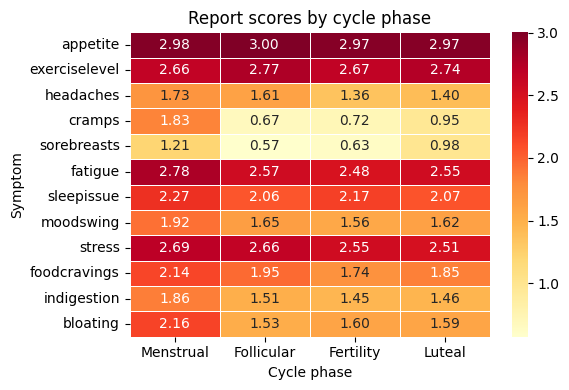

In [52]:
df = interday.dropna(subset=["phase"]).copy()
phase_means = df.groupby("phase")[REPORT_COLS].mean().reindex(PHASE_ORDER)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(phase_means.T, ax=ax, cmap="YlOrRd", annot=True, fmt=".2f", linewidths=0.5)
ax.set_xlabel("Cycle phase")
ax.set_ylabel("Symptom")
ax.set_title("Report scores by cycle phase")
fig.tight_layout()
plt.show()

### Sleep metrics by cycle phase

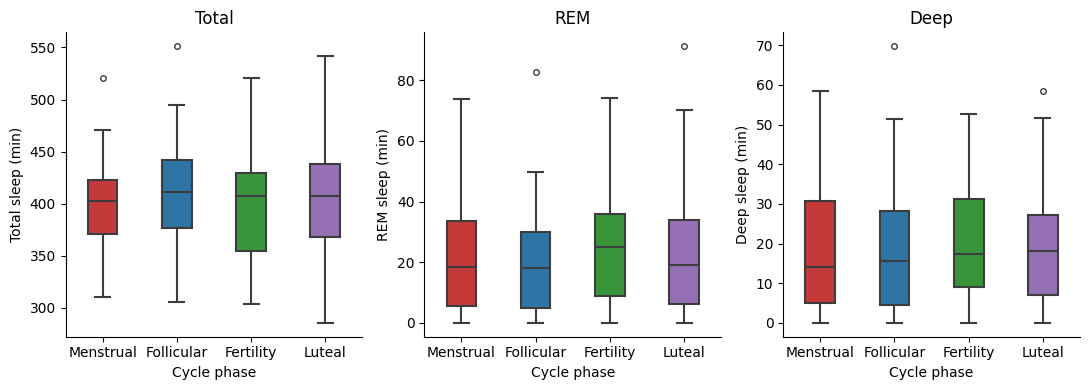

In [53]:
df = interday.dropna(subset=["phase"]).copy()
sleep_vars = ["sleep_min_total", "sleep_min_rem", "sleep_min_deep"]
ylabels = ["Total sleep (min)", "REM sleep (min)", "Deep sleep (min)"]

fig, axes = plt.subplots(1, 3, figsize=(11, 4))

for ax, var, ylabel in zip(axes, sleep_vars, ylabels):
    data = df.groupby(["id", "phase"])[[var]].mean()
    sns.boxplot(data=data, x="phase", y=var,
            hue="phase", palette=PHASE_COLORS, fill=True, saturation=0.8,
            linecolor="auto", linewidth=1.5, width=0.4, order=PHASE_ORDER,
            flierprops={"markersize": 4}, ax=ax)    
    ax.set_xlabel("Cycle phase")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel.split()[0])
    ax.tick_params(axis="x")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.show()